# Unsupervised Learning Association Rule Learning
### Market Basket Analysis of the *Groceries* Dataset

**Assignment:** Association Rule Learning
**Dataset:** `groceries.csv` (Groceries one month of point-of-sale transactions from a typical local grocery outlet)

---

## Objective

Discover relationships between products that customers purchase together, using the **Apriori** algorithm to mine frequent itemsets and derive association rules, then interpret the support / confidence / lift measures and translate them into business recommendations.

## Notebook roadmap

| Section | Assignment question | What is produced |
|---|---|---|
| 1 | Q1 Understand the data | Transaction count, item count, top-10 items + figure |
| 2 | Q2 Frequent itemsets | Apriori itemsets of size ≥ 2 with support values |
| 3 | Q3 Association rules | Rule table with antecedent, consequent, support, confidence, lift |
| 4 | Q4 Understanding the measures | Plain-language reading of three rules |
| 5 | Q5 Interesting rules | Max confidence / max lift / max support rules compared |
| 6 | Q6 Interpret a rule | One rule explained and assessed for strength |
| 7 | Q7 Business application | Shelf placement, bundle, recommender use case |
| 8 | Q8 Understanding association | Causation, high-confidence/low-lift, lift > 1 |

---

## Theoretical background

For an itemset $X$ and a rule $X \Rightarrow Y$ over a transaction database $D$ of $N$ transactions:

$$\text{support}(X) = \frac{|\{t \in D : X \subseteq t\}|}{N}$$

$$\text{support}(X \Rightarrow Y) = \frac{|\{t \in D : X \cup Y \subseteq t\}|}{N}$$

$$\text{confidence}(X \Rightarrow Y) = \frac{\text{support}(X \cup Y)}{\text{support}(X)} = \hat{P}(Y \mid X)$$

$$\text{lift}(X \Rightarrow Y) = \frac{\text{confidence}(X \Rightarrow Y)}{\text{support}(Y)} = \frac{\hat{P}(X \cap Y)}{\hat{P}(X)\,\hat{P}(Y)}$$

- **Support** how *frequent* the pattern is. It measures coverage, not strength.
- **Confidence** how *reliable* the implication is: the conditional probability of the consequent given the antecedent.
- **Lift** how much the antecedent *changes the odds* of the consequent versus buying it at the base rate. Lift is symmetric: $\text{lift}(X \Rightarrow Y) = \text{lift}(Y \Rightarrow X)$.

Apriori exploits the **downward-closure property**: every subset of a frequent itemset is itself frequent. Equivalently, if an itemset is infrequent, none of its supersets can be frequent which is what makes the search tractable.

## 0. Environment setup

`mlxtend` supplies the Apriori implementation. Install it if it is not already present.

In [1]:
# Run once if mlxtend is not installed:
# !pip install mlxtend

In [4]:
import os
import csv
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

# Display / plotting conventions
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
print("Environment ready.")

Environment ready.


---
# 1. Question 1 Understand the Data

## 1.1 Loading the data

The Groceries file is **not** a rectangular table. It is stored in *basket* (transaction) format:
each line is one shopping trip, and the items on that trip are comma-separated. Lines are padded with empty fields to a fixed width, so a naive `pd.read_csv()` would produce mostly-empty columns and would silently mis-handle the ragged rows.

The correct approach is to read it line by line with the `csv` module and build a **list of lists**. Three cleaning steps are applied while parsing:

1. **Strip whitespace** a few item labels carry a trailing space (e.g. `"cream cheese "`), which would otherwise create duplicate items.
2. **Drop empty fields** the padding commas.
3. **De-duplicate within a transaction** association rule mining works on *sets*. A basket that records an item twice must still count as one occurrence, otherwise supports are inflated.

In [5]:
# Portable path resolution: works whether the CSV sits next to the notebook,
# in a data/ subfolder, or in the uploads directory.
CANDIDATES = ["groceries.csv", "data/groceries.csv"]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"groceries.csv not found. Looked in: {CANDIDATES}")
print(f"Reading: {CSV_PATH}")

transactions = []
with open(CSV_PATH, newline="", encoding="utf-8") as fh:
    for row in csv.reader(fh):
        items = {field.strip() for field in row if field.strip()}   # strip + drop blanks + de-duplicate
        if items:                                                   # skip fully empty lines
            transactions.append(sorted(items))

print(f"Parsed {len(transactions):,} non-empty transactions.")
print("\nFirst 5 transactions:")
for i, t in enumerate(transactions[:5], start=1):
    print(f"  {i}. {t}")

Reading: data/groceries.csv
Parsed 9,835 non-empty transactions.

First 5 transactions:
  1. ['citrus fruit', 'margarine', 'ready soups', 'semi-finished bread']
  2. ['coffee', 'tropical fruit', 'yogurt']
  3. ['whole milk']
  4. ['cream cheese', 'meat spreads', 'pip fruit', 'yogurt']
  5. ['condensed milk', 'long life bakery product', 'other vegetables', 'whole milk']


## 1.2 (a) How many transactions? (b) How many distinct items?

In [7]:
n_transactions = len(transactions)
all_items = sorted({item for t in transactions for item in t})
n_items = len(all_items)

basket_sizes = pd.Series([len(t) for t in transactions], name="basket_size")

summary = pd.DataFrame({
    "Metric": [
        "Number of transactions",
        "Number of distinct grocery items",
        "Total items sold (item-transaction pairs)",
        "Mean basket size",
        "Median basket size",
        "Smallest basket",
        "Largest basket",
        "Density of the transaction matrix",
    ],
    "Value": [
        f"{n_transactions:,}",
        f"{n_items}",
        f"{basket_sizes.sum():,}",
        f"{basket_sizes.mean():.2f} items",
        f"{basket_sizes.median():.0f} items",
        f"{basket_sizes.min()} item",
        f"{basket_sizes.max()} items",
        f"{basket_sizes.sum() / (n_transactions * n_items):.4f}",
    ],
})
display(summary.style.hide(axis="index"))

Metric,Value
Number of transactions,"9,835"
Number of distinct grocery items,169
Total items sold (item-transaction pairs),"43,367"
Mean basket size,4.41 items
Median basket size,3 items
Smallest basket,1 item
Largest basket,32 items
Density of the transaction matrix,0.0261


### Answer Q1 (a) and (b)

> **(a) There are 9,835 transactions in the dataset.**
> **(b) There are 169 different grocery items.**

The transaction matrix is extremely **sparse**: its density is about **0.026**, meaning only ~2.6 % of all possible (transaction, item) cells are filled. The average shopper bought only **4.41** of the 169 available items. This sparsity is the reason support thresholds in market-basket analysis must be set very low (1–2 %) a threshold of, say, 10 % would leave almost no itemsets at all.

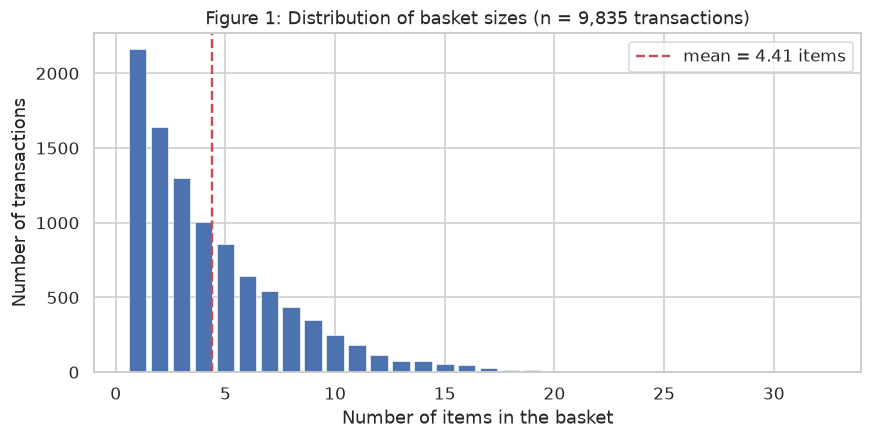

70.8% of baskets contain 5 items or fewer.


In [9]:
# Distribution of basket sizes context for why supports are small
fig, ax = plt.subplots(figsize=(9, 4))
counts = basket_sizes.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvline(basket_sizes.mean(), color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"mean = {basket_sizes.mean():.2f} items")
ax.set_xlabel("Number of items in the basket")
ax.set_ylabel("Number of transactions")
ax.set_title("Figure 1: Distribution of basket sizes (n = 9,835 transactions)")
ax.legend()
plt.savefig(f"{FIG_DIR}/fig1_basket_size_distribution.png")
plt.show()

print(f"{(basket_sizes <= 5).mean():.1%} of baskets contain 5 items or fewer.")

## 1.3 (c) The 10 most frequently purchased items

In [13]:
# we are counting the number of times each item appears across all transactions, which gives us the frequency of each item.
item_counts = (
    pd.Series([item for t in transactions for item in t])
      .value_counts()
      .rename("frequency")
)
# we are calculating the support of each item by dividing its frequency by the total number of transactions.
item_support = (item_counts / n_transactions).rename("support")

top10 = (
    pd.concat([item_counts, item_support], axis=1)
      .head(10)
      .reset_index()
      .rename(columns={"index": "item"})
)
top10.columns = ["Item", "Frequency (count)", "Support (proportion)"]
top10.insert(0, "Rank", range(1, 11))
top10["Support (%)"] = (top10["Support (proportion)"] * 100).round(2)

print("Table 1 Top 10 most frequently purchased items")
display(top10.style.hide(axis="index").format({"Support (proportion)": "{:.4f}"}))

Table 1 Top 10 most frequently purchased items


Rank,Item,Frequency (count),Support (proportion),Support (%)
1,whole milk,2513,0.2555,25.550000
2,other vegetables,1903,0.1935,19.350000
3,rolls/buns,1809,0.1839,18.390000
4,soda,1715,0.1744,17.440000
5,yogurt,1372,0.1395,13.950000
6,bottled water,1087,0.1105,11.050000
7,root vegetables,1072,0.1090,10.900000
8,tropical fruit,1032,0.1049,10.490000
9,shopping bags,969,0.0985,9.850000
10,sausage,924,0.0940,9.400000


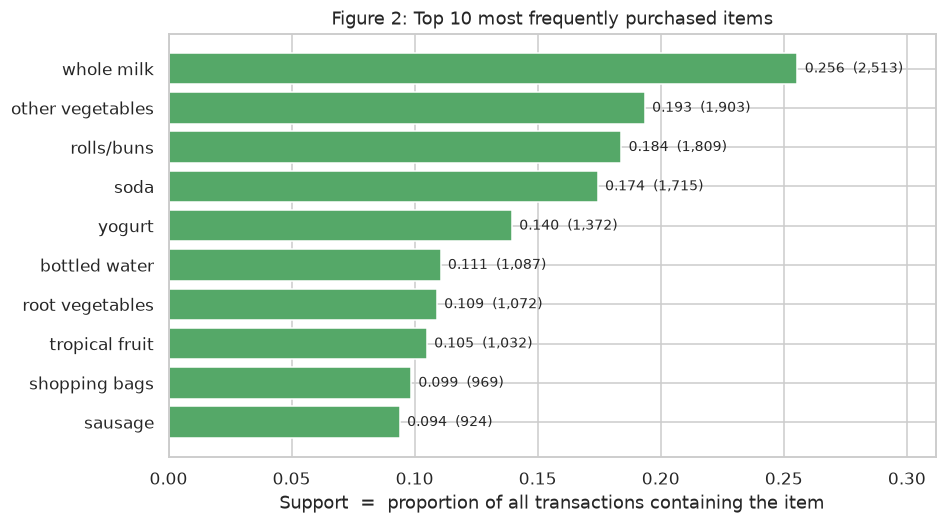

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = top10.iloc[::-1]
bars = ax.barh(plot_df["Item"], plot_df["Support (proportion)"], color="#55A868", edgecolor="white")
for bar, val, cnt in zip(bars, plot_df["Support (proportion)"], plot_df["Frequency (count)"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}  ({cnt:,})", va="center", fontsize=9)
ax.set_xlim(0, top10["Support (proportion)"].max() * 1.22)
ax.set_xlabel("Support  =  proportion of all transactions containing the item")
ax.set_title("Figure 2: Top 10 most frequently purchased items")
plt.savefig(f"{FIG_DIR}/fig2_top10_items.png")
plt.show()

### Answer Q1 (c)

**Table 1 / Figure 2 the 10 most frequently purchased items:**

| Rank | Item | Count | Support |
|---:|---|---:|---:|
| 1 | whole milk | 2,513 | 0.2555 |
| 2 | other vegetables | 1,903 | 0.1935 |
| 3 | rolls/buns | 1,809 | 0.1839 |
| 4 | soda | 1,715 | 0.1744 |
| 5 | yogurt | 1,372 | 0.1395 |
| 6 | bottled water | 1,087 | 0.1105 |
| 7 | root vegetables | 1,072 | 0.1090 |
| 8 | tropical fruit | 1,032 | 0.1049 |
| 9 | shopping bags | 969 | 0.0985 |
| 10 | sausage | 924 | 0.0940 |

**Reading:** *whole milk* appears in roughly **one basket in four** (25.6 %), and no other item exceeds 20 %. The profile is that of a **top-up / convenience shop** rather than a weekly stock-up: staples (milk, bread, vegetables), drinks (soda, bottled water) and fresh produce dominate, while `shopping bags` in 9.9 % of baskets reveals a large share of unplanned visits.

This ranking matters for everything that follows. Because whole milk has such a high base rate, *any* rule pointing to whole milk will inherit a high confidence almost automatically which is exactly the trap that lift is designed to expose (see Q8b).

---
# 2. Question 2 Frequent Itemsets

## 2.1 Encoding the transactions

Apriori needs the data as a **one-hot encoded boolean matrix**: one row per transaction, one column per item, `True` where the item is in the basket. `TransactionEncoder` performs this conversion. 

In [17]:
encoder = TransactionEncoder()
basket_matrix = pd.DataFrame(
    encoder.fit(transactions).transform(transactions),
    columns=encoder.columns_,
)

print(f"One-hot matrix shape: {basket_matrix.shape[0]:,} transactions x {basket_matrix.shape[1]} items")
display(basket_matrix.iloc[:5, :8])

One-hot matrix shape: 9,835 transactions x 169 items


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## 2.2 Choosing the minimum support

The threshold is a deliberate modelling choice, not a default.

- `min_support = 0.01` means an itemset must appear in at least **99 transactions** (1 % of 9,835) to be considered frequent.
- Set it **higher** (e.g. 0.05) and only pairs of the very top sellers survive nothing is learned.
- Set it **lower** (e.g. 0.001) and thousands of itemsets appear, most of them statistical noise backed by fewer than 10 baskets.

Given the sparsity established in Section 1 (mean basket = 4.41 of 169 items), **1 % is the standard choice for this dataset** and is what is used throughout.

In [18]:
# Sensitivity check: how does the threshold change the number of itemsets found?
sensitivity = []
# we will iterate over a list of support thresholds and for each threshold
# we will use the apriori algorithm to find frequent itemsets in the basket_matrix. 
# We will then calculate the sizes of the itemsets and store various statistics about 
# the itemsets found at each threshold in a list of dictionaries called sensitivity.
for thr in [0.05, 0.03, 0.02, 0.015, 0.01, 0.005, 0.002, 0.001]:
    f = apriori(basket_matrix, min_support=thr, use_colnames=True)
    # We will then calculate the sizes of the itemsets and store various statistics about 
    # the itemsets found at each threshold in a list of dictionaries called sensitivity.
    sizes = f["itemsets"].apply(len)
    sensitivity.append({
        "min_support": thr,
        "min transactions": int(np.ceil(thr * n_transactions)),
        "total itemsets": len(f),
        "1-itemsets": int((sizes == 1).sum()),
        "2-itemsets": int((sizes == 2).sum()),
        "3-itemsets": int((sizes == 3).sum()),
        "4+-itemsets": int((sizes >= 4).sum()),
    })

sens_df = pd.DataFrame(sensitivity)
print("Table 2: Sensitivity of the itemset count to the support threshold")
display(sens_df.style.hide(axis="index").format({"min_support": "{:.3f}"}))

Table 2: Sensitivity of the itemset count to the support threshold


min_support,min transactions,total itemsets,1-itemsets,2-itemsets,3-itemsets,4+-itemsets
0.050,492,31,28,3,0,0
0.030,296,63,44,19,0,0
0.020,197,122,59,61,2,0
0.015,148,180,73,101,6,0
0.010,99,333,88,213,32,0
0.005,50,1001,120,605,264,12
0.002,20,4223,147,1674,1991,411
0.001,10,13492,157,2981,6831,3523


In [19]:
MIN_SUPPORT = 0.01

frequent_itemsets = apriori(basket_matrix, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets["items"] = frequent_itemsets["itemsets"].apply(lambda s: ", ".join(sorted(s)))
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}  ->  {len(frequent_itemsets)} frequent itemsets in total")
print(frequent_itemsets["length"].value_counts().sort_index().rename("count").to_frame().T)

min_support = 0.01  ->  333 frequent itemsets in total
length   1    2   3
count   88  213  32


## 2.3 (a) and (b) Frequent itemsets of two or more products, with their support values

In [20]:
multi_itemsets = (
    frequent_itemsets[frequent_itemsets["length"] >= 2]
    .sort_values("support", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(multi_itemsets)} frequent itemsets contain 2 or more products "
      f"({(multi_itemsets['length'] == 2).sum()} pairs, {(multi_itemsets['length'] == 3).sum()} triples).")

top_itemsets = multi_itemsets.head(15).copy()
top_itemsets["Rank"] = range(1, len(top_itemsets) + 1)
top_itemsets["Transactions"] = (top_itemsets["support"] * n_transactions).round().astype(int)
top_itemsets["Support (%)"] = (top_itemsets["support"] * 100).round(2)

print("\nTable 3: Top 15 frequent itemsets of size >= 2 (min_support = 1%)")
display(
    top_itemsets[["Rank", "items", "length", "support", "Support (%)", "Transactions"]]
    .rename(columns={"items": "Itemset", "length": "Size", "support": "Support"})
    .style.hide(axis="index").format({"Support": "{:.4f}"})
)

245 frequent itemsets contain 2 or more products (213 pairs, 32 triples).

Table 3: Top 15 frequent itemsets of size >= 2 (min_support = 1%)


Rank,Itemset,Size,Support,Support (%),Transactions
1,"other vegetables, whole milk",2,0.0748,7.480000,736
2,"rolls/buns, whole milk",2,0.0566,5.660000,557
3,"whole milk, yogurt",2,0.0560,5.600000,551
4,"root vegetables, whole milk",2,0.0489,4.890000,481
5,"other vegetables, root vegetables",2,0.0474,4.740000,466
6,"other vegetables, yogurt",2,0.0434,4.340000,427
7,"other vegetables, rolls/buns",2,0.0426,4.260000,419
8,"tropical fruit, whole milk",2,0.0423,4.230000,416
9,"soda, whole milk",2,0.0401,4.010000,394
10,"rolls/buns, soda",2,0.0383,3.830000,377


In [21]:
# The largest itemsets found at this threshold
triples = multi_itemsets[multi_itemsets["length"] == 3].sort_values("support", ascending=False)
print(f"Table 4: All {len(triples)} frequent 3-itemsets at min_support = 1%")
display(
    triples[["items", "support"]]
    .assign(**{"Transactions": (triples["support"] * n_transactions).round().astype(int)})
    .rename(columns={"items": "Itemset", "support": "Support"})
    .reset_index(drop=True)
    .style.hide(axis="index").format({"Support": "{:.4f}"})
)

Table 4: All 32 frequent 3-itemsets at min_support = 1%


Itemset,Support,Transactions
"other vegetables, root vegetables, whole milk",0.0232,228
"other vegetables, whole milk, yogurt",0.0223,219
"other vegetables, rolls/buns, whole milk",0.0179,176
"other vegetables, tropical fruit, whole milk",0.0171,168
"rolls/buns, whole milk, yogurt",0.0156,153
"tropical fruit, whole milk, yogurt",0.0151,149
"other vegetables, whipped/sour cream, whole milk",0.0146,144
"root vegetables, whole milk, yogurt",0.0145,143
"other vegetables, soda, whole milk",0.0139,137
"other vegetables, pip fruit, whole milk",0.0135,133


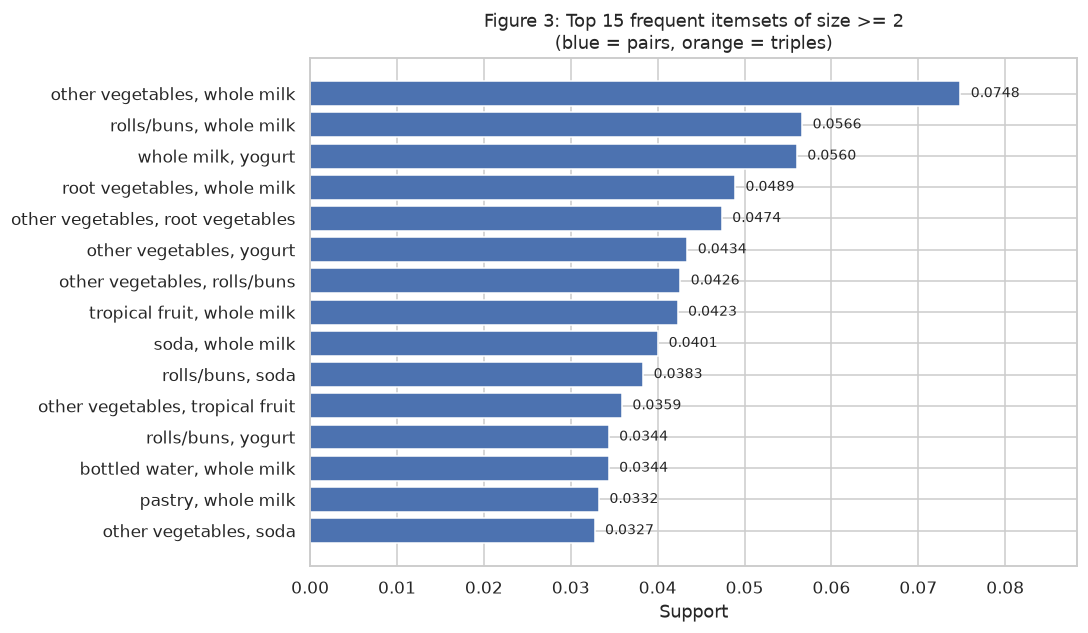

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
pl = top_itemsets.iloc[::-1]
colors = ["#4C72B0" if s == 2 else "#DD8452" for s in pl["length"]]
bars = ax.barh(pl["items"], pl["support"], color=colors, edgecolor="white")
for bar, val in zip(bars, pl["support"]):
    ax.text(val + 0.0012, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)
ax.set_xlim(0, top_itemsets["support"].max() * 1.18)
ax.set_xlabel("Support")
ax.set_title("Figure 3: Top 15 frequent itemsets of size >= 2\n(blue = pairs, orange = triples)")
plt.savefig(f"{FIG_DIR}/fig3_frequent_itemsets.png")
plt.show()

### Answer Q2 (a) and (b)

At a 1 % minimum support, Apriori finds **245 frequent itemsets containing two or more products** (213 pairs and 32 triples) far more than the ten required. The ten highest-support ones are:

| # | Itemset | Support | Transactions |
|---:|---|---:|---:|
| 1 | {whole milk, other vegetables} | 0.0748 | 736 |
| 2 | {whole milk, rolls/buns} | 0.0566 | 557 |
| 3 | {whole milk, yogurt} | 0.0560 | 551 |
| 4 | {whole milk, root vegetables} | 0.0489 | 481 |
| 5 | {other vegetables, root vegetables} | 0.0474 | 466 |
| 6 | {other vegetables, yogurt} | 0.0434 | 427 |
| 7 | {other vegetables, rolls/buns} | 0.0426 | 419 |
| 8 | {whole milk, tropical fruit} | 0.0423 | 416 |
| 9 | {whole milk, soda} | 0.0401 | 394 |
| 10 | {rolls/buns, soda} | 0.0383 | 377 |

The largest frequent itemsets at this threshold are of **size 3** for example `{whole milk, other vegetables, root vegetables}` at 0.0232 and
`{whole milk, other vegetables, yogurt}` at 0.0223. No 4-itemset reaches 1 % support, which is a direct consequence of the short baskets seen in Figure 1.

### Answer Q2 (c) Which itemset has the highest support?

> **`{whole milk, other vegetables}`, with a support of 0.0748 (7.48 %, i.e. 736 of the 9,835 transactions).**

### Answer Q2 (d) What does the support value tell you about customers' purchasing behaviour?

Support is the **empirical probability that a randomly chosen basket contains the whole itemset** it measures how *common* a buying pattern is, and therefore how much of the store's traffic a decision based on that pattern would actually touch.

Four things follow from the numbers above:

1. **Even the strongest pattern covers a small minority of trips.** The top itemset appears in only 7.5 % of baskets, so roughly **92.5 % of customers do not buy milk and vegetables together**. Support keeps the analysis honest about scale: "customers buy X and Y together" never means "most customers".
2. **Support is driven by popularity, not by affinity.** Every itemset in the top ten is built from items in the top-10 single-item list. Two items can co-occur often simply because both are individually popular, with no real relationship between them. That is precisely why support alone is not enough and why confidence and lift are needed (Section 3).
3. **The pattern is a staples cluster.** Dairy, vegetables, bread and fruit repeatedly co-occur the signature of routine household replenishment rather than a themed occasion.
4. **Support sets the floor for business viability.** An itemset at 1 % support corresponds to ~99 baskets a month. A promotion built on it may not be worth the shelf space, whereas one at 7.5 % (736 baskets) plausibly is. Support is the measure that converts a statistical pattern into an expected transaction volume.

---
# 3. Question 3 Association Rules

## 3.1 Generating the rules

Every frequent itemset of size $k \ge 2$ can be split into an antecedent and a consequent in $2^k - 2$ ways, and each split is a candidate rule. Rules are then filtered on a minimum confidence.

`min_threshold = 0.25` on confidence is used here: a rule is retained only if the consequent is actually bought in **at least a quarter** of the baskets containing the antecedent. Below that the rule is too unreliable to act on commercially.

A helper turns the `frozenset` columns that `mlxtend` returns into readable text.

In [23]:
MIN_CONFIDENCE = 0.25

rules = association_rules(
    frequent_itemsets[["support", "itemsets"]],
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

def fs_to_str(fs):
    return "{" + ", ".join(sorted(fs)) + "}"

rules["antecedent"]   = rules["antecedents"].apply(fs_to_str)
rules["consequent"]   = rules["consequents"].apply(fs_to_str)
rules["rule"]         = rules["antecedent"] + "  ->  " + rules["consequent"]
rules["ant_len"]      = rules["antecedents"].apply(len)
rules["transactions"] = (rules["support"] * n_transactions).round().astype(int)

rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE}  ->  {len(rules)} association rules")
print(f"  rules with a single-item antecedent : {(rules['ant_len'] == 1).sum()}")
print(f"  rules with a two-item antecedent    : {(rules['ant_len'] == 2).sum()}")
print(f"  rules with lift > 1                 : {(rules['lift'] > 1).sum()}")
print(f"  rules with lift < 1                 : {(rules['lift'] < 1).sum()}")

min_support = 0.01, min_confidence = 0.25  ->  170 association rules
  rules with a single-item antecedent : 96
  rules with a two-item antecedent    : 74
  rules with lift > 1                 : 169
  rules with lift < 1                 : 1


## 3.2 (a) and (b) At least 10 rules, with antecedent, consequent, support, confidence and lift

The table below reports the **top 15 rules ranked by lift** lift being the measure that isolates genuine association from mere popularity. `leverage` and `conviction` are included as supporting diagnostics:

- **leverage** $= \text{supp}(X \cup Y) - \text{supp}(X)\,\text{supp}(Y)$ the *absolute* excess co-occurrence over independence (lift expresses the same idea as a ratio).
- **conviction** $= \dfrac{1 - \text{supp}(Y)}{1 - \text{conf}(X \Rightarrow Y)}$ how often the rule would be wrong if $X$ and $Y$ were independent; $\infty$ means the rule is never violated.

In [24]:
RULE_COLS = ["antecedent", "consequent", "support", "confidence", "lift",
             "leverage", "conviction", "transactions"]

top_rules = rules.head(15).copy()
top_rules.insert(0, "Rule #", range(1, len(top_rules) + 1))

print("Table 5: Top 15 association rules ranked by lift "
      f"(min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE})")
display(
    top_rules[["Rule #"] + RULE_COLS]
    .rename(columns={"antecedent": "Antecedent (X)", "consequent": "Consequent (Y)",
                     "support": "Support", "confidence": "Confidence", "lift": "Lift",
                     "leverage": "Leverage", "conviction": "Conviction",
                     "transactions": "N baskets"})
    .style.hide(axis="index")
    .format({"Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}",
             "Leverage": "{:.5f}", "Conviction": "{:.3f}"})
    .background_gradient(subset=["Lift"], cmap="YlOrRd")
)

Table 5: Top 15 association rules ranked by lift (min_support = 0.01, min_confidence = 0.25)


Rule #,Antecedent (X),Consequent (Y),Support,Confidence,Lift,Leverage,Conviction,N baskets
1,"{citrus fruit, other vegetables}",{root vegetables},0.0104,0.3592,3.2950,0.00722,1.390,102
2,"{other vegetables, tropical fruit}",{root vegetables},0.0123,0.3428,3.1448,0.00839,1.356,121
3,{beef},{root vegetables},0.0174,0.3314,3.0404,0.01167,1.333,171
4,"{citrus fruit, root vegetables}",{other vegetables},0.0104,0.5862,3.0296,0.00695,1.949,102
5,"{root vegetables, tropical fruit}",{other vegetables},0.0123,0.5845,3.0210,0.00823,1.941,121
6,"{other vegetables, whole milk}",{root vegetables},0.0232,0.3098,2.8421,0.01503,1.291,228
7,"{curd, whole milk}",{yogurt},0.0101,0.3852,2.7614,0.00642,1.400,99
8,"{other vegetables, yogurt}",{root vegetables},0.0129,0.2974,2.7287,0.00818,1.268,127
9,"{other vegetables, yogurt}",{tropical fruit},0.0123,0.2834,2.7005,0.00775,1.249,121
10,"{other vegetables, rolls/buns}",{root vegetables},0.0122,0.2864,2.6275,0.00756,1.249,120


In [25]:
# The same rules ranked by confidence, for comparison
print("Table 6: Top 10 association rules ranked by confidence")
display(
    rules.sort_values("confidence", ascending=False).head(10)[RULE_COLS]
    .reset_index(drop=True)
    .rename(columns={"antecedent": "Antecedent (X)", "consequent": "Consequent (Y)",
                     "support": "Support", "confidence": "Confidence", "lift": "Lift",
                     "leverage": "Leverage", "conviction": "Conviction",
                     "transactions": "N baskets"})
    .style.hide(axis="index")
    .format({"Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}",
             "Leverage": "{:.5f}", "Conviction": "{:.3f}"})
)

Table 6: Top 10 association rules ranked by confidence


Antecedent (X),Consequent (Y),Support,Confidence,Lift,Leverage,Conviction,N baskets
"{citrus fruit, root vegetables}",{other vegetables},0.0104,0.5862,3.0296,0.00695,1.949,102
"{root vegetables, tropical fruit}",{other vegetables},0.0123,0.5845,3.0210,0.00823,1.941,121
"{curd, yogurt}",{whole milk},0.0101,0.5824,2.2791,0.00565,1.783,99
"{butter, other vegetables}",{whole milk},0.0115,0.5736,2.2449,0.00637,1.746,113
"{root vegetables, tropical fruit}",{whole milk},0.0120,0.5700,2.2310,0.00662,1.732,118
"{root vegetables, yogurt}",{whole milk},0.0145,0.5630,2.2034,0.00794,1.704,143
"{domestic eggs, other vegetables}",{whole milk},0.0123,0.5525,2.1623,0.00661,1.664,121
"{whipped/sour cream, yogurt}",{whole milk},0.0109,0.5245,2.0527,0.00558,1.566,107
"{rolls/buns, root vegetables}",{whole milk},0.0127,0.5230,2.0469,0.00650,1.561,125
"{other vegetables, pip fruit}",{whole milk},0.0135,0.5175,2.0254,0.00685,1.543,133


### Answer Q3 (a) and (b)

The analysis produces **170 association rules** at `min_support = 0.01` and `min_confidence = 0.25`. Ten of the strongest by lift, with all four required quantities:

| # | Antecedent | Consequent | Support | Confidence | Lift |
|---:|---|---|---:|---:|---:|
| 1 | {citrus fruit, other vegetables} | {root vegetables} | 0.0104 | 0.359 | 3.295 |
| 2 | {tropical fruit, other vegetables} | {root vegetables} | 0.0123 | 0.343 | 3.145 |
| 3 | {beef} | {root vegetables} | 0.0174 | 0.331 | 3.040 |
| 4 | {citrus fruit, root vegetables} | {other vegetables} | 0.0104 | 0.586 | 3.030 |
| 5 | {tropical fruit, root vegetables} | {other vegetables} | 0.0123 | 0.585 | 3.021 |
| 6 | {whole milk, other vegetables} | {root vegetables} | 0.0232 | 0.310 | 2.842 |
| 7 | {curd, whole milk} | {yogurt} | 0.0101 | 0.385 | 2.761 |
| 8 | {other vegetables, yogurt} | {root vegetables} | 0.0129 | 0.297 | 2.729 |
| 9 | {other vegetables, yogurt} | {tropical fruit} | 0.0123 | 0.283 | 2.701 |
| 10 | {other vegetables, rolls/buns} | {root vegetables} | 0.0122 | 0.286 | 2.628 |

Two structural observations:

- **Fresh produce dominates the high-lift region.** Rules linking citrus fruit, tropical fruit, root vegetables and other vegetables occupy the top of the table. These are *cooking-basket* patterns customers assembling ingredients for a meal and they are genuinely associated rather than merely popular.
- **`{beef} → {root vegetables}` (lift 3.04) is the strongest single-item rule.** It reflects a clear culinary pattern (a roast or stew), and because its antecedent needs only one item it is the easiest of the high-lift rules to act on operationally.

In [30]:
# # Figure 4: the classic support / confidence / lift scatter
# fig, ax = plt.subplots(figsize=(9.5, 6))
# sc = ax.scatter(rules["support"], rules["confidence"],
#                 c=rules["lift"], s=42 + rules["lift"] * 22,
#                 cmap="viridis", alpha=0.82, edgecolors="white", linewidths=0.5)
# cbar = plt.colorbar(sc, ax=ax); cbar.set_label("Lift")
# ax.axhline(MIN_CONFIDENCE, color="grey", ls=":", lw=1)
# ax.axvline(MIN_SUPPORT, color="grey", ls=":", lw=1)

# for _, r in rules.nlargest(3, "lift").iterrows():
#     ax.annotate(r["rule"].replace("  ->  ", " -> "), (r["support"], r["confidence"]),
#                 textcoords="offset points", xytext=(11, 9), fontsize=7.5, color="#333333")
# for _, r in rules.nlargest(1, "support").iterrows():
#     ax.annotate(r["rule"].replace("  ->  ", " -> "), (r["support"], r["confidence"]),
#                 textcoords="offset points", xytext=(-12, -20), fontsize=7.5,
#                 ha="right", color="#333333")

# ax.set_xlim(rules["support"].min() - 0.004, rules["support"].max() * 1.10)
# ax.set_ylim(MIN_CONFIDENCE - 0.03, rules["confidence"].max() + 0.05)
# ax.set_xlabel("Support"); ax.set_ylabel("Confidence")
# ax.set_title(f"Figure 4: Support vs Confidence for all {len(rules)} rules (colour and size = lift)")
# plt.savefig(f"{FIG_DIR}/fig4_support_confidence_lift.png")
# plt.show()

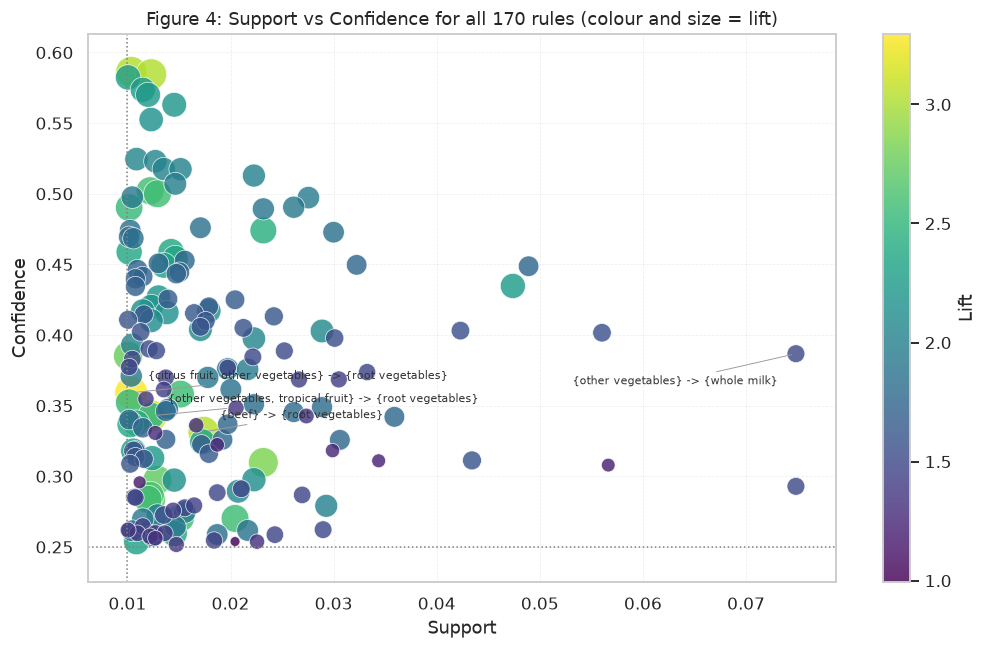

In [31]:
# Figure 4: the classic support / confidence / lift scatter
fig, ax = plt.subplots(figsize=(9.5, 6))

# normalized marker size (so lift actually reads visually)
lift = rules["lift"].to_numpy()
sizes = 42 + 420 * (lift - lift.min()) / (lift.max() - lift.min() + 1e-9)

sc = ax.scatter(rules["support"], rules["confidence"],
                c=rules["lift"], s=sizes,
                cmap="viridis", alpha=0.82, edgecolors="white", linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("Lift")

# pad limits so the threshold lines are actually visible
x_range = rules["support"].max() - rules["support"].min() + 1e-9
y_range = rules["confidence"].max() - rules["confidence"].min() + 1e-9

ax.axhline(MIN_CONFIDENCE, color="grey", ls=":", lw=1, zorder=1)
ax.axvline(MIN_SUPPORT,    color="grey", ls=":", lw=1, zorder=1)

for _, r in rules.nlargest(3, "lift").iterrows():
    ax.annotate(r["rule"].replace("  ->  ", " -> "),
                (r["support"], r["confidence"]),
                textcoords="offset points", xytext=(11, 9),
                fontsize=7.5, color="#333333",
                arrowprops=dict(arrowstyle="-", color="#999", lw=0.6,
                                shrinkA=0, shrinkB=3))
for _, r in rules.nlargest(1, "support").iterrows():
    ax.annotate(r["rule"].replace("  ->  ", " -> "),
                (r["support"], r["confidence"]),
                textcoords="offset points", xytext=(-12, -20),
                fontsize=7.5, ha="right", color="#333333",
                arrowprops=dict(arrowstyle="-", color="#999", lw=0.6,
                                shrinkA=0, shrinkB=3))

ax.set_xlim(rules["support"].min()    - 0.06 * x_range,
            rules["support"].max()    + 0.06 * x_range)
ax.set_ylim(rules["confidence"].min() - 0.08 * y_range,
            rules["confidence"].max() + 0.08 * y_range)
ax.set_xlabel("Support"); ax.set_ylabel("Confidence")
ax.set_title(f"Figure 4: Support vs Confidence for all {len(rules)} rules (colour and size = lift)")
ax.grid(True, ls="--", lw=0.5, alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_support_confidence_lift.png", dpi=150, bbox_inches="tight")
plt.show()

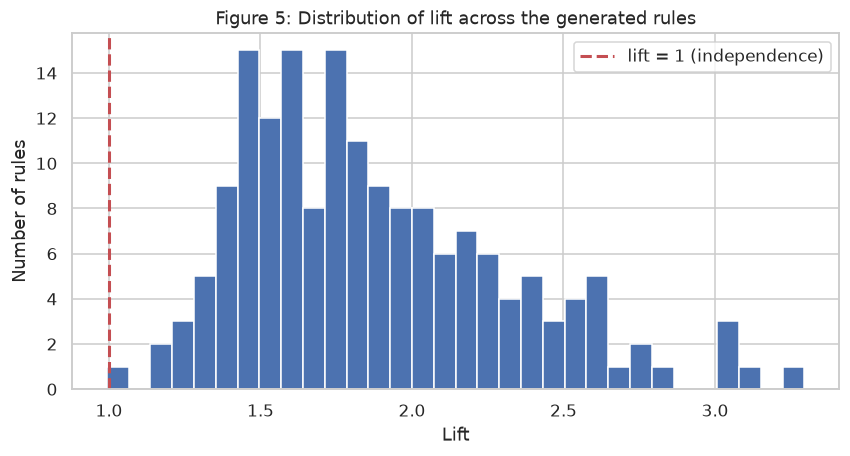

Median lift: 1.778   |   Range: 0.993 to 3.295


In [32]:
# Figure 5: lift distribution: how many rules beat independence, and by how much
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(rules["lift"], bins=32, color="#4C72B0", edgecolor="white")
ax.axvline(1.0, color="#C44E52", ls="--", lw=2, label="lift = 1 (independence)")
ax.set_xlabel("Lift"); ax.set_ylabel("Number of rules")
ax.set_title("Figure 5: Distribution of lift across the generated rules")
ax.legend()
plt.savefig(f"{FIG_DIR}/fig5_lift_distribution.png")
plt.show()

print(f"Median lift: {rules['lift'].median():.3f}   |   "
      f"Range: {rules['lift'].min():.3f} to {rules['lift'].max():.3f}")

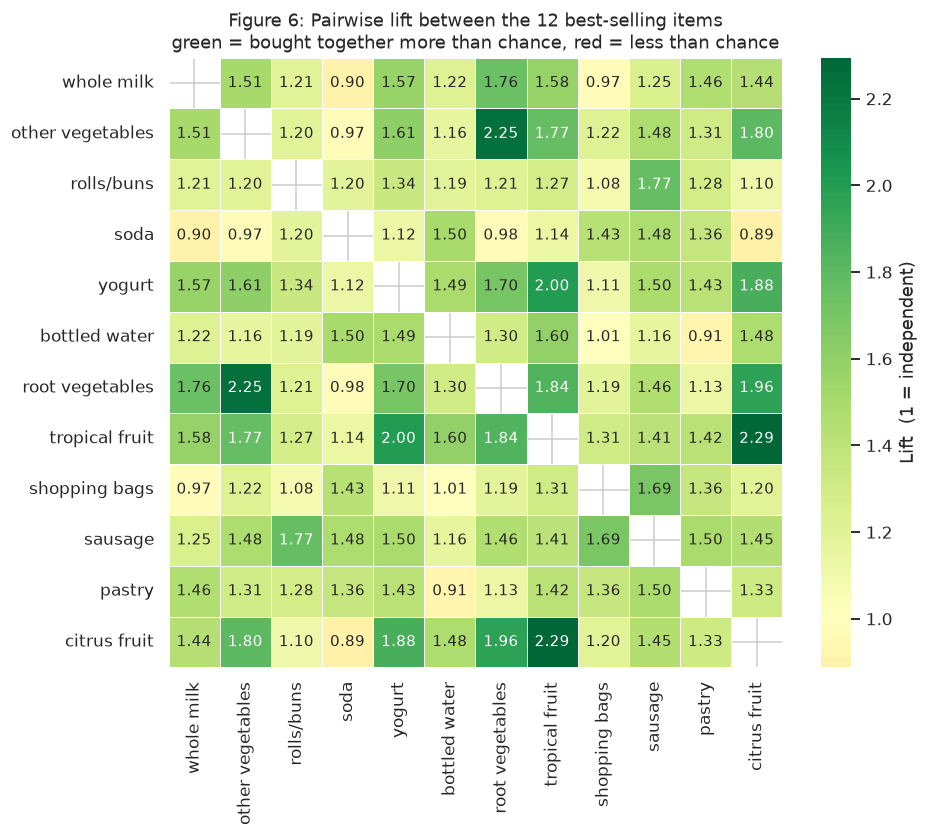

In [33]:
# Figure 6: item-to-item lift matrix for the 12 best-selling items
top_items = item_counts.head(12).index.tolist()
lift_matrix = pd.DataFrame(np.nan, index=top_items, columns=top_items, dtype=float)

for a, b in combinations(top_items, 2):
    both = (basket_matrix[a] & basket_matrix[b]).mean()
    lv = both / (basket_matrix[a].mean() * basket_matrix[b].mean())
    lift_matrix.loc[a, b] = lift_matrix.loc[b, a] = lv

fig, ax = plt.subplots(figsize=(9, 7.2))
sns.heatmap(lift_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Lift  (1 = independent)"}, ax=ax)
ax.set_title("Figure 6: Pairwise lift between the 12 best-selling items\n"
             "green = bought together more than chance, red = less than chance")
plt.savefig(f"{FIG_DIR}/fig6_lift_heatmap.png")
plt.show()

**Reading Figure 6.** The heatmap makes the popularity-versus-association distinction visible at a glance. `whole milk` the single most popular item sits near lift 1.0 against almost everything, because it is bought on so many trips that it is nearly independent of the rest of the basket. The strong green cells cluster among the *fresh produce* items (root vegetables, other vegetables, tropical fruit), confirming the cooking-basket pattern seen in the rule table. Red cells such as `soda`–`root vegetables` mark **negative associations**: a convenience/drinks trip and a cooking trip are two different kinds of visit.

---
# 4. Question 4: Understanding the Measures

Three rules are selected to span the interesting range: one high-lift produce rule, one high-confidence rule, and one high-support "popular staples" rule.

In [34]:
SELECTED = [
    ("{citrus fruit, other vegetables}", "{root vegetables}"),
    ("{curd, whole milk}",               "{yogurt}"),
    ("{other vegetables}",               "{whole milk}"),
]

sel = pd.concat(
    [rules[(rules["antecedent"] == a) & (rules["consequent"] == c)] for a, c in SELECTED]
).reset_index(drop=True)
sel.insert(0, "Rule", ["R1", "R2", "R3"])

print("Table 7: The three rules chosen for detailed interpretation")
display(
    sel[["Rule", "antecedent", "consequent", "antecedent support", "consequent support",
         "support", "confidence", "lift", "transactions"]]
    .rename(columns={"antecedent": "X", "consequent": "Y",
                     "antecedent support": "supp(X)", "consequent support": "supp(Y)",
                     "support": "supp(X&Y)", "confidence": "conf", "lift": "lift",
                     "transactions": "N baskets"})
    .style.hide(axis="index")
    .format({"supp(X)": "{:.4f}", "supp(Y)": "{:.4f}", "supp(X&Y)": "{:.4f}",
             "conf": "{:.4f}", "lift": "{:.4f}"})
)

Table 7: The three rules chosen for detailed interpretation


Rule,X,Y,supp(X),supp(Y),supp(X&Y),conf,lift,N baskets
R1,"{citrus fruit, other vegetables}",{root vegetables},0.0289,0.1090,0.0104,0.3592,3.2950,102
R2,"{curd, whole milk}",{yogurt},0.0261,0.1395,0.0101,0.3852,2.7614,99
R3,{other vegetables},{whole milk},0.1935,0.2555,0.0748,0.3868,1.5136,736


In [35]:
# Verify the measures from first principles rather than trusting the library output
print("Manual verification of every reported measure\n" + "=" * 74)
for _, r in sel.iterrows():
    X = set(r["antecedents"]); Y = set(r["consequents"])
    n_X    = sum(1 for t in transactions if X <= set(t))
    n_XY   = sum(1 for t in transactions if (X | Y) <= set(t))
    n_Y    = sum(1 for t in transactions if Y <= set(t))
    supp   = n_XY / n_transactions
    conf   = n_XY / n_X
    lift   = conf / (n_Y / n_transactions)
    ok = (np.isclose(supp, r["support"]) and np.isclose(conf, r["confidence"])
          and np.isclose(lift, r["lift"]))
    print(f"\n{r['Rule']}:  {r['antecedent']} -> {r['consequent']}")
    print(f"   baskets with X       = {n_X:>5}")
    print(f"   baskets with X and Y = {n_XY:>5}")
    print(f"   baskets with Y       = {n_Y:>5}")
    print(f"   support    = {n_XY}/{n_transactions}       = {supp:.4f}")
    print(f"   confidence = {n_XY}/{n_X}          = {conf:.4f}")
    print(f"   lift       = {conf:.4f}/{n_Y / n_transactions:.4f} = {lift:.4f}")
    print(f"   matches mlxtend: {ok}")

Manual verification of every reported measure

R1:  {citrus fruit, other vegetables} -> {root vegetables}
   baskets with X       =   284
   baskets with X and Y =   102
   baskets with Y       =  1072
   support    = 102/9835       = 0.0104
   confidence = 102/284          = 0.3592
   lift       = 0.3592/0.1090 = 3.2950
   matches mlxtend: True

R2:  {curd, whole milk} -> {yogurt}
   baskets with X       =   257
   baskets with X and Y =    99
   baskets with Y       =  1372
   support    = 99/9835       = 0.0101
   confidence = 99/257          = 0.3852
   lift       = 0.3852/0.1395 = 2.7614
   matches mlxtend: True

R3:  {other vegetables} -> {whole milk}
   baskets with X       =  1903
   baskets with X and Y =   736
   baskets with Y       =  2513
   support    = 736/9835       = 0.0748
   confidence = 736/1903          = 0.3868
   lift       = 0.3868/0.2555 = 1.5136
   matches mlxtend: True


### Answer Q4

---

#### Rule R1 `{citrus fruit, other vegetables} → {root vegetables}`
*support = 0.0104, confidence = 0.359, lift = 3.295*

**(a) Support.** Citrus fruit, other vegetables **and** root vegetables all appear together in **1.04 % of all shopping trips 102 of the 9,835 baskets**. The pattern is real but narrow: about one trip in a hundred. Any action taken on this rule reaches only a small slice of store traffic.

**(b) Confidence.** Of the customers who bought citrus fruit and other vegetables, **35.9 % also bought root vegetables** roughly one in three. This is the conditional probability $\hat{P}(\text{root vegetables} \mid \text{citrus fruit, other vegetables})$. It is a *one-directional* reading: it says nothing about how often root-vegetable buyers pick up citrus fruit.

**(c) Lift.** Root vegetables are bought in 10.9 % of baskets overall. Among this particular group of customers the rate is 35.9 % **3.295 times the base rate**. Lift 3.3 means the presence ofcitrus fruit and other vegetables in a basket *more than triples* the odds of root vegetables appearing too. This is by far the strongest association in the dataset, and because lift is symmetric, the fresh-produce link works in both directions.

---

#### Rule R2 `{curd, whole milk} → {yogurt}`
*support = 0.0101, confidence = 0.385, lift = 2.761*

**(a) Support.** Curd, whole milk and yogurt occur together in **1.01 % of transactions (99 baskets)** just above the 1 % floor, so this rule barely qualified as frequent.

**(b) Confidence.** **38.5 % of customers who bought curd and whole milk also bought yogurt.** Note that this is the highest confidence among the three even though its support is the lowest the two measures are independent of one another.

**(c) Lift.** Yogurt's base rate is 13.95 %. For curd-plus-milk buyers it is 38.5 %, i.e. **2.76 times higher**. The interpretation is a coherent *dairy-run* shopper: someone already buying two dairy products is far more likely than average to buy a third. This rule's value lies in category logic, not in volume.

---

#### Rule R3 `{other vegetables} → {whole milk}`
*support = 0.0748, confidence = 0.387, lift = 1.514*

**(a) Support.** Other vegetables and whole milk appear together in **7.48 % of transactions (736 baskets)** the **highest support of any rule in the analysis**, and roughly seven times the coverage of R1. In volume terms this is the most commercially significant pattern found.

**(b) Confidence.** **38.7 % of baskets containing other vegetables also contain whole milk.** Superficially impressive, but it must be read against the base rate.

**(c) Lift.** Whole milk is in 25.6 % of *all* baskets. Vegetable buyers take it 38.7 % of the time only **1.51 times** the base rate. So the association is real but **modest**: most of that 38.7 % confidence is explained simply by how popular whole milk is, not by any special connection to vegetables. R3 is the clearest illustration of why confidence must never be read on its own.

---

**Summary of the contrast.** R3 has 7× the support of R1 but less than half its lift; R2 has the highest confidence but the lowest support. The three measures answer three different questions *how often?* (support), *how reliably?* (confidence), *how much better than chance?* (lift) and a rule must be judged on all three at once.

---
# 5. Question 5 Find Interesting Rules

In [36]:
best = {
    "Highest CONFIDENCE": rules.loc[rules["confidence"].idxmax()],
    "Highest LIFT":       rules.loc[rules["lift"].idxmax()],
    "Highest SUPPORT":    rules.loc[rules["support"].idxmax()],
}

extremes = pd.DataFrame([
    {"Criterion": k, "Antecedent": v["antecedent"], "Consequent": v["consequent"],
     "Support": v["support"], "Confidence": v["confidence"], "Lift": v["lift"],
     "N baskets": v["transactions"]}
    for k, v in best.items()
])

print("Table 8: The extreme rules under each criterion")
display(extremes.style.hide(axis="index")
        .format({"Support": "{:.4f}", "Confidence": "{:.4f}", "Lift": "{:.4f}"}))

print("\nAre they the same rule?")
ids = {k: (v["antecedent"], v["consequent"]) for k, v in best.items()}
for k, v in ids.items():
    print(f"  {k:<20}: {v[0]} -> {v[1]}")
print(f"\n  All three identical? {len(set(ids.values())) == 1}"
      f"   ({len(set(ids.values()))} distinct rules)")

Table 8: The extreme rules under each criterion


Criterion,Antecedent,Consequent,Support,Confidence,Lift,N baskets
Highest CONFIDENCE,"{citrus fruit, root vegetables}",{other vegetables},0.0104,0.5862,3.0296,102
Highest LIFT,"{citrus fruit, other vegetables}",{root vegetables},0.0104,0.3592,3.2950,102
Highest SUPPORT,{other vegetables},{whole milk},0.0748,0.3868,1.5136,736



Are they the same rule?
  Highest CONFIDENCE  : {citrus fruit, root vegetables} -> {other vegetables}
  Highest LIFT        : {citrus fruit, other vegetables} -> {root vegetables}
  Highest SUPPORT     : {other vegetables} -> {whole milk}

  All three identical? False   (3 distinct rules)


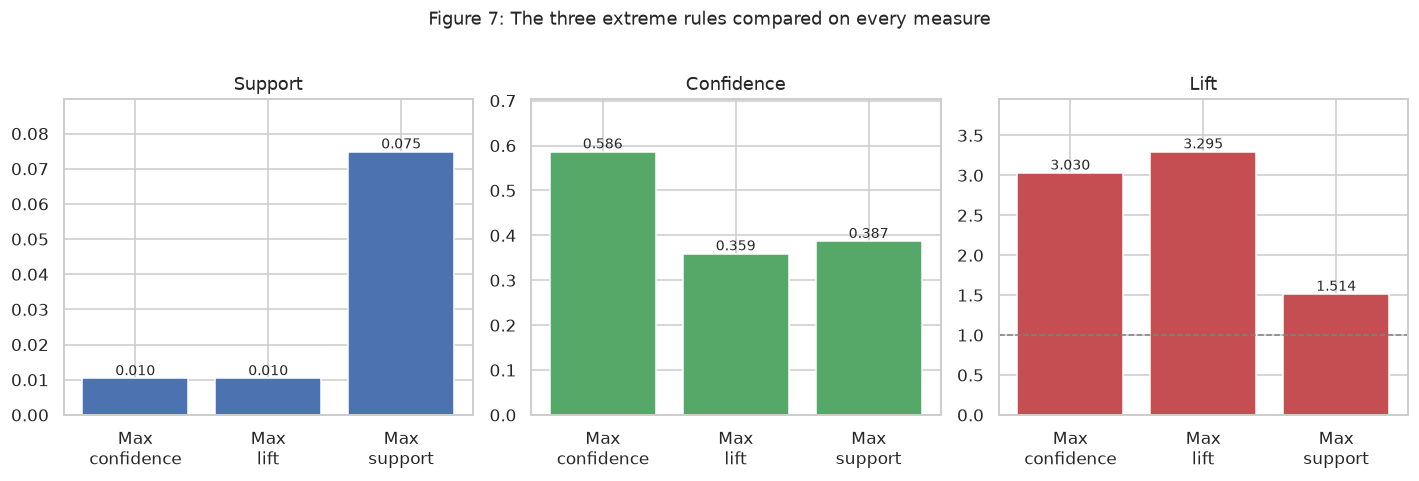

In [37]:
# Figure 7: the three extreme rules profiled on all measures
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
metrics = [("support", "Support", "#4C72B0"),
           ("confidence", "Confidence", "#55A868"),
           ("lift", "Lift", "#C44E52")]
labels = ["Max\nconfidence", "Max\nlift", "Max\nsupport"]

for ax, (col, name, colour) in zip(axes, metrics):
    vals = [best["Highest CONFIDENCE"][col], best["Highest LIFT"][col], best["Highest SUPPORT"][col]]
    bars = ax.bar(labels, vals, color=colour, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(name)
    ax.set_ylim(0, max(vals) * 1.2)
    if col == "lift":
        ax.axhline(1.0, color="grey", ls="--", lw=1)

fig.suptitle("Figure 7: The three extreme rules compared on every measure", y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig7_extreme_rules.png")
plt.show()

### Answer Q5

**(a) Rule with the highest confidence**

> **`{citrus fruit, root vegetables} → {other vegetables}`** confidence **0.586**
> (support 0.0104, lift 3.030)

Nearly **59 % of the customers who buy citrus fruit and root vegetables also buy other vegetables** the most *reliable* prediction available.

**(b) Rule with the highest lift**

> **`{citrus fruit, other vegetables} → {root vegetables}`** lift **3.295**
> (support 0.0104, confidence 0.359)

The **strongest genuine association**: this basket combination more than triples the chance of root vegetables appearing.

**(c) Rule with the highest support**

> **`{other vegetables} → {whole milk}`** support **0.0748**
> (confidence 0.387, lift 1.514)
>
> Its mirror image, `{whole milk} → {other vegetables}`, shares the same 0.0748 support support is
> symmetric, so both directions of a pair always tie. They differ in confidence (0.387 vs 0.293)
> because the antecedents have different base rates.

**(d) Are these the same rule? Explain.**

**No all three are different rules.** They are not even the same *pair* of items in two cases, and the third involves entirely different products.

The reason is that the three measures optimise three different, partly conflicting objectives:

| | What it maximises | Which rules win |
|---|---|---|
| **Support** | Coverage how many baskets the pattern touches | Rules among **very popular items**, since $\text{supp}(X \cup Y) \le \min(\text{supp}(X), \text{supp}(Y))$ |
| **Confidence** | Reliability of the prediction | Rules with a **narrow antecedent** and a **common consequent** |
| **Lift** | Excess over independence | Rules with **specific, mutually reinforcing** items typically *not* the most popular ones |

The structural conflict is unavoidable. **Support and lift pull in opposite directions.** A high support requires both items to be popular, but popular items have high base rates, and lift divides by the consequent's base rate so popularity *suppresses* lift. This is exactly what the data shows: the max-support rule has the **lowest lift of the three (1.51)**, while the max-lift rule has **one-seventh of its support (0.0104)**.

Confidence and lift diverge for the same reason. `{citrus fruit, root vegetables} → {other vegetables}` wins on confidence (0.586) because *other vegetables* is a common consequent (19.4 % base rate). `{citrus fruit, other vegetables} → {root vegetables}` wins on lift (3.295) because *root vegetables* is rarer (10.9 % base rate) a lower confidence of 0.359 still represents a bigger multiple of a
smaller base. Interestingly, the two rules are built from the **same three products** split differently, and they share an identical support of 0.0104 a reminder that support belongs to the *itemset*, whereas confidence and lift belong to the *direction of the rule*.

**Practical conclusion:** no single measure identifies the "best" rule.
- Use **support** to size the commercial opportunity,
- **confidence** to decide whether a recommendation will actually be acted on,
- **lift** to confirm the pattern is more than an artefact of popularity.

A rule worth deploying should clear a sensible floor on all three.

---
# 6. Question 6: Interpret a Rule

The rule selected is of the required `{Product A, Product B} → {Product C}` form:

> ### `{tropical fruit, root vegetables} → {other vegetables}`

In [38]:
chosen = rules[(rules["antecedent"] == "{root vegetables, tropical fruit}") &
               (rules["consequent"] == "{other vegetables}")].iloc[0]

X, Y = set(chosen["antecedents"]), set(chosen["consequents"])
n_X  = sum(1 for t in transactions if X <= set(t))
n_XY = sum(1 for t in transactions if (X | Y) <= set(t))
n_Y  = sum(1 for t in transactions if Y <= set(t))

print(f"RULE:  {chosen['antecedent']}  ->  {chosen['consequent']}")
print("=" * 74)
print(f"  Baskets containing tropical fruit AND root vegetables : {n_X:>5}")
print(f"  ... of which also contain other vegetables            : {n_XY:>5}")
print(f"  Baskets containing other vegetables (anywhere)        : {n_Y:>5}")
print("-" * 74)
print(f"  Support     = {chosen['support']:.4f}   ({n_XY} of {n_transactions} baskets, "
      f"{chosen['support']*100:.2f}%)")
print(f"  Confidence  = {chosen['confidence']:.4f}   ({n_XY}/{n_X} = "
      f"{chosen['confidence']*100:.1f}% of antecedent baskets)")
print(f"  Base rate   = {n_Y/n_transactions:.4f}   (other vegetables in "
      f"{n_Y/n_transactions*100:.1f}% of all baskets)")
print(f"  Lift        = {chosen['lift']:.4f}   ({chosen['confidence']*100:.1f}% / "
      f"{n_Y/n_transactions*100:.1f}% = {chosen['lift']:.2f}x the base rate)")
print(f"  Leverage    = {chosen['leverage']:.5f}")
print(f"  Conviction  = {chosen['conviction']:.3f}")

RULE:  {root vegetables, tropical fruit}  ->  {other vegetables}
  Baskets containing tropical fruit AND root vegetables :   207
  ... of which also contain other vegetables            :   121
  Baskets containing other vegetables (anywhere)        :  1903
--------------------------------------------------------------------------
  Support     = 0.0123   (121 of 9835 baskets, 1.23%)
  Confidence  = 0.5845   (121/207 = 58.5% of antecedent baskets)
  Base rate   = 0.1935   (other vegetables in 19.3% of all baskets)
  Lift        = 3.0210   (58.5% / 19.3% = 3.02x the base rate)
  Leverage    = 0.00823
  Conviction  = 1.941


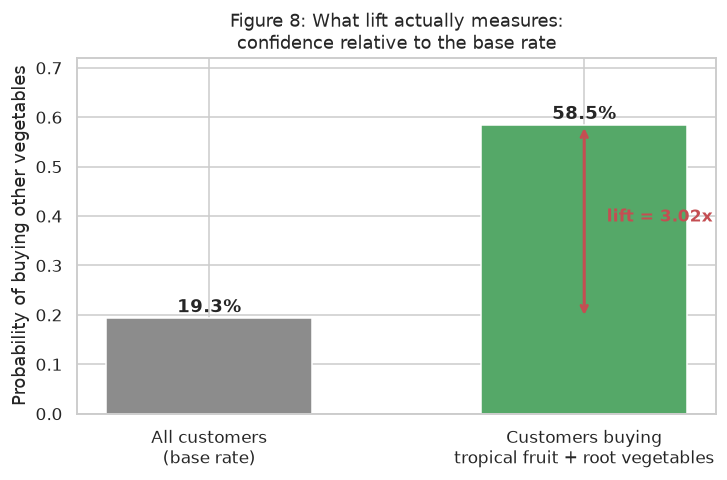

In [39]:
# Figure 8: confidence against the base rate, which is what lift measures
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(["All customers\n(base rate)", "Customers buying\ntropical fruit + root vegetables"],
              [n_Y / n_transactions, chosen["confidence"]],
              color=["#8C8C8C", "#55A868"], edgecolor="white", width=0.55)
for b, v in zip(bars, [n_Y / n_transactions, chosen["confidence"]]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.annotate("", xy=(1, chosen["confidence"]), xytext=(1, n_Y / n_transactions),
            arrowprops=dict(arrowstyle="<->", color="#C44E52", lw=2))
ax.text(1.06, (chosen["confidence"] + n_Y / n_transactions) / 2,
        f"lift = {chosen['lift']:.2f}x", color="#C44E52", fontsize=11, fontweight="bold")
ax.set_ylabel("Probability of buying other vegetables")
ax.set_ylim(0, 0.72)
ax.set_title("Figure 8: What lift actually measures:\nconfidence relative to the base rate")
plt.savefig(f"{FIG_DIR}/fig8_rule_interpretation.png")
plt.show()

### Answer Q6

#### The rule in plain language

> **Customers who purchase tropical fruit and root vegetables also tend to purchase other vegetables.**

Spelled out with the numbers:

- **Support (0.0123).** Out of every 1,000 shopping trips, about **12 contain all three** tropical fruit, root vegetables *and* other vegetables. In absolute terms, **121 of the 9,835 baskets**.
- **Confidence (0.585).** Of the **207 customers** who bought tropical fruit together with root vegetables, **121 almost 59 % also put other vegetables in the basket.** Put simply: if you see those two items on the belt, it is close to a coin-flip *in favour* of vegetables following.
- **Lift (3.021).** Across the whole store, other vegetables are in **19.4 %** of baskets. Within this customer group the figure rises to **58.5 %** **three times the normal rate** (Figure 8).

#### Is this a strong or a weak association?

**This is a strong association**, on three independent grounds:

1. **Lift of 3.02 is far above 1.** Independence would give lift = 1.0; observed co-occurrence is three times what chance alone predicts. Across the 170 rules generated, the median lift is about 1.8 and only a handful exceed 3.0 this rule sits in the top few percent.
2. **Confidence of 58.5 % is high in absolute terms and relative to the base rate.** Predicting "this customer will buy other vegetables" from those two items is right more often than wrong, whereas the same prediction made blindly for a random customer would be wrong four times in five.
3. **Positive leverage and conviction above 1** confirm the same conclusion from two other angles: the excess co-occurrence over independence is positive, and the rule is violated far less often than independence would imply.

**The one caveat is coverage.** Support is only **1.23 %**, so the rule describes a *small but very coherent* customer segment likely shoppers assembling ingredients for a cooked meal. It is a **strong but narrow** rule: excellent for targeted, in-context recommendations (an app suggesting vegetables once fruit and root vegetables are in the cart), but too small a share of traffic to justify a store-wide campaign on its own.

This nuance is the practical heart of the exercise: **strength (lift/confidence) and reach (support) are separate properties, and a rule must be assessed on both before it is acted on.**

---
# 7. Question 7: Business Application

Taking the perspective of a supermarket manager, the rules are converted into three concrete decisions. The analysis below ranks candidates by lift for *placement* decisions (where affinity matters) and cross-checks support for *volume* (where reach matters).

In [41]:
# Candidate item pairs for co-location: strong mutual affinity + enough volume to matter
pairs = []
for a, b in combinations(item_counts.head(25).index, 2):
    both = (basket_matrix[a] & basket_matrix[b]).mean()
    if both < 0.01:
        continue
    lv = both / (basket_matrix[a].mean() * basket_matrix[b].mean())
    pairs.append({
        "Item A": a, "Item B": b,
        "Support": both,
        "Baskets": int(round(both * n_transactions)),
        "Lift": lv,
        "conf A->B": both / basket_matrix[a].mean(),
        "conf B->A": both / basket_matrix[b].mean(),
    })

pair_df = pd.DataFrame(pairs).sort_values("Lift", ascending=False).reset_index(drop=True)
print("Table 9: Best candidate pairs for shelf co-location (support >= 1%, ranked by lift)")
display(pair_df.head(10).style.hide(axis="index")
        .format({"Support": "{:.4f}", "Lift": "{:.3f}", "conf A->B": "{:.3f}", "conf B->A": "{:.3f}"}))

Table 9: Best candidate pairs for shelf co-location (support >= 1%, ranked by lift)


Item A,Item B,Support,Baskets,Lift,conf A->B,conf B->A
tropical fruit,pip fruit,0.0204,201,2.575,0.195,0.270
whipped/sour cream,butter,0.0102,100,2.560,0.142,0.183
tropical fruit,citrus fruit,0.0199,196,2.295,0.190,0.241
other vegetables,root vegetables,0.0474,466,2.247,0.245,0.435
citrus fruit,pip fruit,0.0138,136,2.209,0.167,0.183
root vegetables,whipped/sour cream,0.0171,168,2.186,0.157,0.238
root vegetables,pork,0.0136,134,2.168,0.125,0.236
root vegetables,butter,0.0129,127,2.138,0.118,0.233
other vegetables,whipped/sour cream,0.0289,284,2.082,0.149,0.403
yogurt,whipped/sour cream,0.0207,204,2.074,0.149,0.289


In [42]:
# Candidate bundles: 3-itemsets scored on lift over the independence baseline
bundle_rows = []
for _, row in triples.iterrows():
    items3 = sorted(row["itemsets"])
    indep = np.prod([basket_matrix[i].mean() for i in items3])
    bundle_rows.append({
        "Bundle": " + ".join(items3),
        "Support": row["support"],
        "Baskets": int(round(row["support"] * n_transactions)),
        "Expected if independent": indep,
        "Lift over independence": row["support"] / indep,
    })

bundle_df = (pd.DataFrame(bundle_rows)
             .sort_values("Lift over independence", ascending=False)
             .reset_index(drop=True))
print("Table 10: Candidate product bundles (frequent 3-itemsets, ranked by lift over independence)")
display(bundle_df.head(8).style.hide(axis="index")
        .format({"Support": "{:.4f}", "Expected if independent": "{:.5f}",
                 "Lift over independence": "{:.2f}"}))

Table 10: Candidate product bundles (frequent 3-itemsets, ranked by lift over independence)


Bundle,Support,Baskets,Expected if independent,Lift over independence
citrus fruit + other vegetables + root vegetables,0.0104,102,0.00175,5.94
other vegetables + root vegetables + tropical fruit,0.0123,121,0.00221,5.56
curd + whole milk + yogurt,0.0101,99,0.00190,5.30
other vegetables + whipped/sour cream + yogurt,0.0102,100,0.00193,5.25
other vegetables + root vegetables + yogurt,0.0129,127,0.00294,4.39
other vegetables + tropical fruit + yogurt,0.0123,121,0.00283,4.34
other vegetables + root vegetables + whole milk,0.0232,228,0.00539,4.30
whipped/sour cream + whole milk + yogurt,0.0109,107,0.00256,4.26


### Answer Q7

#### (a) Two products that could be placed close to each other

> **Root vegetables and other vegetables.**

**Justification.** The pairwise lift between them is **2.246** with a support of **4.74 % (466 baskets)** the rare combination of *strong affinity* **and** *meaningful volume*. Confidence runs high in both directions (43.5 % of root-vegetable buyers take other vegetables; 24.5 % the other way), so the placement pays off regardless of which item brought the customer to the aisle.
The same rule appears repeatedly at the top of Table 5 with lift above 2.8 when combined with citrus or tropical fruit.

A second, higher-affinity option is **beef and root vegetables** (lift 3.04 as a rule). Placing a root-vegetable display beside the butchery counter targets the meal-preparation shopper directly. Because these sit in different departments, a **secondary cross-merchandising display** is the practical form this takes, rather than a full layout change.

**What to avoid:** placing *whole milk* next to anything on the strength of its co-occurrence numbers. Its high co-occurrence with everything is a popularity artefact (lifts near 1.0 across Figure 6). Indeed, standard practice deliberately places milk *far* from the entrance so that customers walk past other categories to reach it.

#### (b) One possible product bundle

> **The "Fresh Meal Basket": whole milk + other vegetables + root vegetables.**

**Justification.** This is a frequent 3-itemset with support **0.0232 (228 baskets, the highest of any triple)**, and it occurs roughly **4.3 times more often than independence would predict**. The rule `{whole milk, other vegetables} → {root vegetables}` carries confidence 0.310 and lift 2.842, so a third of the customers who already hold two of the three items are natural buyers of the third.

Practically: a discounted bundle of milk, a mixed-vegetable pack and a root-vegetable pack. The strategic logic is to **use the two high-traffic items to move the lower-traffic one** root vegetables appear in only 10.9 % of baskets against whole milk's 25.6 %, so the bundle converts existing footfall into incremental root-vegetable sales rather than discounting items customers
would have bought anyway.

Table 10 shows that the *highest-affinity* triple is actually **citrus fruit + other vegetables + root vegetables** (5.94× independence), and a second strong option is the **"Dairy Trio": curd + whole milk + yogurt** (5.30×). Both are deliberately passed over
for the headline bundle: each covers only ~1 % of baskets, so they suit a **targeted recipe promotion or loyalty offer** rather than the mass-market bundle the Fresh Meal Basket supports.

#### (c) One example of using association rules to recommend products

> **Real-time checkout and e-commerce cart recommendations.**

When a customer's basket already contains *tropical fruit* and *root vegetables*, the system matches the rule `{tropical fruit, root vegetables} → {other vegetables}` (confidence **58.5 %**, lift **3.02**) and prompts on the self-checkout screen, in the app cart, or on a printed receipt coupon *"Customers who bought these also bought other vegetables."*

This works where a generic promotion does not, for three reasons:

1. **It is contextual.** The recommendation fires only for the segment the rule actually describes, instead of pushing the same offer at everyone.
2. **Confidence sets a realistic expectation.** At 58.5 %, the majority of targeted customers were plausible buyers already, so the conversion rate will be far above that of an untargeted prompt.
3. **Lift guarantees incrementality.** A lift of 3.02 means the suggestion is not simply riding on an item's baseline popularity. By contrast, recommending *whole milk* to everyone (lift ≈ 1.5 at best) would mostly remind customers of something they were going to buy regardless, spending promotional budget for no incremental revenue.

The same rule base also supports **personalised loyalty coupons** (issue a root-vegetable discount to customers whose history shows the citrus-plus-vegetables pattern) and **inventory planning** (items in a high-lift itemset should be reordered together, since a stock-out in one depresses sales of the other).

---
# 8. Question 8: Understanding Association

## 8.1 Empirical demonstrations

Before answering, the two claims that can be tested on the data are tested.

In [44]:
# (b) A rule with reasonable confidence but essentially no lift
low_lift = rules.nsmallest(6, "lift")[["antecedent", "consequent", "support",
                                       "confidence", "consequent support", "lift"]]
print("Table 11: Rules with the LOWEST lift: decent confidence, no real association")
display(low_lift.reset_index(drop=True)
        .rename(columns={"antecedent": "Antecedent", "consequent": "Consequent",
                         "support": "Support", "confidence": "Confidence",
                         "consequent support": "Base rate of Y", "lift": "Lift"})
        .style.hide(axis="index")
        .format({"Support": "{:.4f}", "Confidence": "{:.4f}",
                 "Base rate of Y": "{:.4f}", "Lift": "{:.4f}"}))

Table 11: Rules with the LOWEST lift: decent confidence, no real association


Antecedent,Consequent,Support,Confidence,Base rate of Y,Lift
{bottled beer},{whole milk},0.0204,0.2538,0.2555,0.9932
{salty snack},{whole milk},0.0112,0.2957,0.2555,1.1573
{rolls/buns},{whole milk},0.0566,0.3079,0.2555,1.2050
{bottled water},{whole milk},0.0344,0.3109,0.2555,1.2169
{sausage},{whole milk},0.0299,0.3182,0.2555,1.2453
{coffee},{whole milk},0.0187,0.3222,0.2555,1.2611


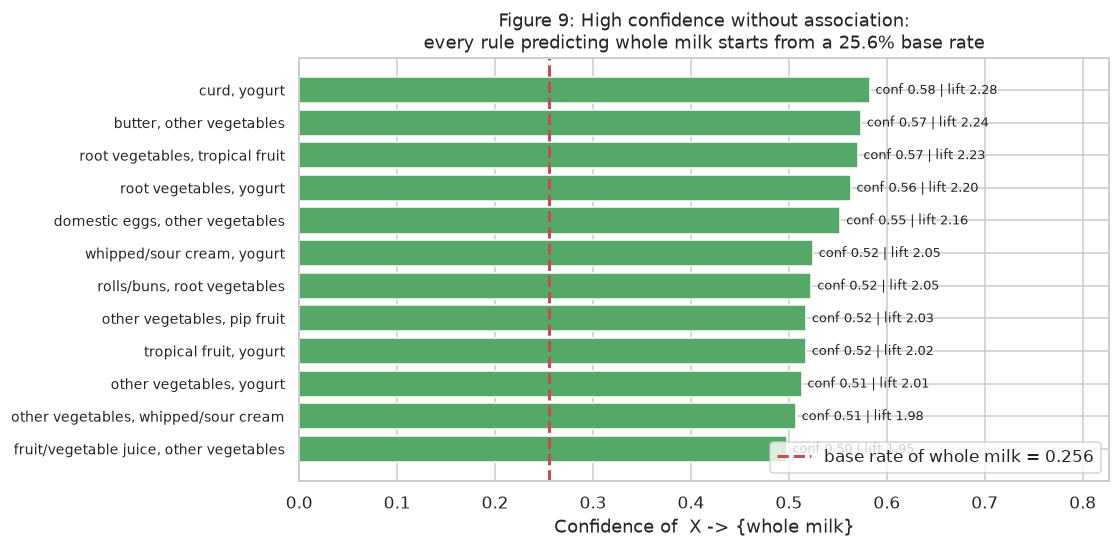

In [45]:
# Figure 9: confidence is not association: the same confidence can mean very different lifts
milk_rules = (rules[rules["consequent"] == "{whole milk}"]
              .sort_values("confidence", ascending=False).head(12))
base_milk = basket_matrix["whole milk"].mean()

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(milk_rules))
ax.barh(y, milk_rules["confidence"], color=np.where(milk_rules["lift"] > 1.5, "#55A868", "#DD8452"),
        edgecolor="white")
ax.axvline(base_milk, color="#C44E52", ls="--", lw=2,
           label=f"base rate of whole milk = {base_milk:.3f}")
ax.set_yticks(y)
ax.set_yticklabels([a.strip("{}") for a in milk_rules["antecedent"]], fontsize=9)
for i, (c, l) in enumerate(zip(milk_rules["confidence"], milk_rules["lift"])):
    ax.text(c + 0.006, i, f"conf {c:.2f} | lift {l:.2f}", va="center", fontsize=8.5)
ax.invert_yaxis()
ax.set_xlim(0, milk_rules["confidence"].max() * 1.42)
ax.set_xlabel("Confidence of  X -> {whole milk}")
ax.set_title("Figure 9: High confidence without association:\n"
             "every rule predicting whole milk starts from a 25.6% base rate")
ax.legend(loc="lower right")
plt.savefig(f"{FIG_DIR}/fig9_confidence_vs_lift.png")
plt.show()

In [46]:
# (a) Confidence is directional; lift is symmetric. Demonstrated on one pair.
a, b = "other vegetables", "whole milk"
p_a, p_b = basket_matrix[a].mean(), basket_matrix[b].mean()
p_ab = (basket_matrix[a] & basket_matrix[b]).mean()

print("Asymmetry of confidence vs symmetry of lift\n" + "=" * 62)
print(f"  conf({a} -> {b}) = {p_ab / p_a:.4f}")
print(f"  conf({b} -> {a}) = {p_ab / p_b:.4f}   <- different")
print(f"  lift({a} -> {b}) = {p_ab / (p_a * p_b):.4f}")
print(f"  lift({b} -> {a}) = {p_ab / (p_b * p_a):.4f}   <- identical")
print("\nA measure that is symmetric cannot encode a direction of influence,")
print("and therefore cannot express causation.")

Asymmetry of confidence vs symmetry of lift
  conf(other vegetables -> whole milk) = 0.3868
  conf(whole milk -> other vegetables) = 0.2929   <- different
  lift(other vegetables -> whole milk) = 1.5136
  lift(whole milk -> other vegetables) = 1.5136   <- identical

A measure that is symmetric cannot encode a direction of influence,
and therefore cannot express causation.


### Answer Q8

#### (a) Does an association rule prove that one product *causes* customers to buy another? Explain.

> **No. Association rules establish correlation statistical co-occurrence and never causation.**

Association rule mining counts how often items appear together in historical baskets. Co-occurrence is a property of the data; causation is a claim about a mechanism that generates the data, and no amount of counting can bridge that gap. Four specific reasons:

1. **The measures are built from co-occurrence counts alone.** Support, confidence and lift are all functions of $\hat{P}(X)$, $\hat{P}(Y)$ and $\hat{P}(X \cap Y)$. Nothing in those quantities records the *order* in which items entered the basket, the customer's intention, or what would have happened otherwise.

2. **Lift is mathematically symmetric** demonstrated in the cell above: $\text{lift}(X \Rightarrow Y) = \text{lift}(Y \Rightarrow X)$ exactly. If the measure cannot even distinguish a direction, it certainly cannot identify a cause. (Confidence *is* asymmetric, but only because it divides by a different base rate, not because it detects influence.)

3. **Confounding is the usual explanation.** `{tropical fruit, root vegetables} → {other vegetables}` does not mean buying fruit *makes* people buy vegetables. A **latent common cause** the intention to cook a particular meal, a household's dietary habits, a recipe, a payday, a seasonal holiday drives all three purchases simultaneously. The items are effects of a shared cause, not causes of one another.

4. **Establishing causation requires intervention, not observation.** The causal question is counterfactual: *would this customer have bought other vegetables had they not bought the fruit?* Historical transaction data cannot answer it. Only a controlled experiment an A/B test where the store randomly promotes item X to one group and not to another, then measures sales of Y can support a causal claim.

**Why this matters commercially.** A manager who mistakes correlation for causation may deep-discount item X expecting sales of Y to follow. If the true driver was the meal occasion, the promotion simply gives away margin on X while Y sells exactly as before. The correct use of a rule is **predictive and contextual** ("given this basket, what else is likely?"), not **causal** ("push X to sell Y").

#### (b) Why might a rule have high confidence but low lift?

> **Because confidence ignores the base rate of the consequent, while lift divides by it.**

From the definition, $\text{lift} = \text{confidence} / \text{support}(Y)$. Whenever the consequent is **very common on its own**, even a high confidence is unimpressive, because a high proportion of *all* baskets contain it anyway. Formally, confidence answers $\hat{P}(Y \mid X)$, whereas lift compares $\hat{P}(Y \mid X)$ against $\hat{P}(Y)$ only the comparison reveals whether $X$ told us
anything new.

**The clearest example in this dataset** (Table 11, Figure 9):

> `{bottled beer} → {whole milk}` **confidence 0.254, lift 0.993**

A quarter of beer buyers also buy whole milk. Taken alone that sounds like a pattern worth acting on. But whole milk is in **25.6 %** of *all* baskets, so beer buyers take milk at very slightly *below* the store-wide rate. Lift 0.993 < 1 means the two items are, if anything, **marginally negatively associated** knowing a customer bought beer makes milk *less* likely, not more. The apparent signal was entirely an artefact of whole milk's popularity.

Figure 9 generalises the point: *every* rule pointing at whole milk inherits a confidence floor near 0.256 regardless of the antecedent, so confidence alone cannot rank them.

**The general rule:** high confidence + low lift ⇒ the consequent is a **best-seller** that most customers buy anyway. Such rules are **not actionable** recommending whole milk to beer buyers produces no incremental sales, only lost margin if a discount is attached. This is exactly why lift (or leverage, or conviction) must always be inspected alongside confidence.

#### (c) What does a lift value greater than 1 indicate?

> **A lift above 1 indicates a positive association: the items appear together more often than would
> be expected if purchases of the antecedent and consequent were statistically independent.**

Since $\text{lift}(X \Rightarrow Y) = \dfrac{\hat{P}(X \cap Y)}{\hat{P}(X)\hat{P}(Y)}$, and independence means $\hat{P}(X \cap Y) = \hat{P}(X)\hat{P}(Y)$, the value is read against a baseline of exactly 1:

| Lift | Meaning | Example from this analysis |
|---|---|---|
| **> 1** | **Positive association** buying X makes Y *more* likely than the base rate | `{citrus fruit, other vegetables} → {root vegetables}`, lift **3.295** |
| **= 1** | **Independence** X carries no information about Y | `{bottled beer} → {whole milk}`, lift **0.993** |
| **< 1** | **Negative association / substitution** buying X makes Y *less* likely | the red cells in Figure 6, e.g. `soda`–`root vegetables` |

Concretely, lift **3.295** means the combination occurs **3.3 times more often than chance alone predicts**; equivalently, the presence of citrus fruit and other vegetables raises the probability of root vegetables from the base rate of 10.9 % to 35.9 %.

Three qualifications are worth stating:

- **Lift > 1 is a necessary but not a sufficient condition for a useful rule.** A lift of 5 on a rule covering 0.1 % of baskets is statistically interesting and commercially negligible support must be checked alongside it.
- **Lift is unbounded above but compressed below.** It can reach large positive values, yet cannot fall below 0, which makes negative associations harder to spot on the same scale.
- **Lift > 1 still does not mean causation** see (a). It only says the co-occurrence exceeds what independence predicts.

---
# 9. Conclusion and Summary of Results

## 9.1 Consolidated results

In [47]:
final_summary = pd.DataFrame({
    "Question": ["Q1a", "Q1b", "Q1c", "Q2a", "Q2c", "Q3a",
                 "Q5a", "Q5b", "Q5c", "Q5d"],
    "Result": [
        f"{n_transactions:,} transactions",
        f"{n_items} distinct items",
        f"Most frequent item: {item_counts.index[0]} ({item_support.iloc[0]:.4f})",
        f"{len(multi_itemsets)} frequent itemsets of size >= 2 at min_support = {MIN_SUPPORT}",
        f"Highest-support itemset: {multi_itemsets.iloc[0]['items']} "
        f"({multi_itemsets.iloc[0]['support']:.4f})",
        f"{len(rules)} rules at min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE}",
        f"{best['Highest CONFIDENCE']['rule']}  (conf = {best['Highest CONFIDENCE']['confidence']:.4f})",
        f"{best['Highest LIFT']['rule']}  (lift = {best['Highest LIFT']['lift']:.4f})",
        f"{best['Highest SUPPORT']['rule']}  (supp = {best['Highest SUPPORT']['support']:.4f})",
        f"Three different rules ({len(set(ids.values()))} distinct)",
    ],
})
print("Table 12: Consolidated answers")
display(final_summary.style.hide(axis="index"))

Table 12: Consolidated answers


Question,Result
Q1a,"9,835 transactions"
Q1b,169 distinct items
Q1c,Most frequent item: whole milk (0.2555)
Q2a,245 frequent itemsets of size >= 2 at min_support = 0.01
Q2c,"Highest-support itemset: other vegetables, whole milk (0.0748)"
Q3a,"170 rules at min_support = 0.01, min_confidence = 0.25"
Q5a,"{citrus fruit, root vegetables} -> {other vegetables} (conf = 0.5862)"
Q5b,"{citrus fruit, other vegetables} -> {root vegetables} (lift = 3.2950)"
Q5c,{other vegetables} -> {whole milk} (supp = 0.0748)
Q5d,Three different rules (3 distinct)


In [48]:
# Export the full result tables for the written report
rules.sort_values("lift", ascending=False)[RULE_COLS].to_csv("data/association_rules_all.csv", index=False)
multi_itemsets[["items", "length", "support"]].to_csv("data/frequent_itemsets.csv", index=False)
top10.to_csv("data/top10_items.csv", index=False)

print("Exported:")
for f in ["data/association_rules_all.csv", "data/frequent_itemsets.csv", "data/top10_items.csv"]:
    print(f"  {f}")
print(f"\nFigures saved in ./{FIG_DIR}/:")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")

Exported:
  data/association_rules_all.csv
  data/frequent_itemsets.csv
  data/top10_items.csv

Figures saved in ./figures/:
  fig1_basket_size_distribution.png
  fig2_top10_items.png
  fig3_frequent_itemsets.png
  fig4_support_confidence_lift.png
  fig5_lift_distribution.png
  fig6_lift_heatmap.png
  fig7_extreme_rules.png
  fig8_rule_interpretation.png
  fig9_confidence_vs_lift.png


## 9.2 Discussion

**What the analysis found.** The Groceries dataset records **9,835 transactions over 169 items**, with an average basket of only **4.41 items** a sparse, convenience-oriented shopping pattern. Apriori at a 1 % support threshold identified **245 frequent itemsets of size two or more**, from which **170 association rules** were derived at 25 % minimum confidence. The strongest patterns are concentrated in **fresh produce**: citrus fruit, tropical fruit, root vegetables and other vegetables form a tightly interconnected cluster with lifts above 3.0, interpretable as meal-preparation baskets.

**The central methodological lesson.** The three measures answer different questions and routinely disagree. The highest-support rule (`{other vegetables} → {whole milk}`, 7.5 % of baskets) has the **lowest lift** of the rules examined (1.51), while the highest-lift rule
(`{citrus fruit, other vegetables} → {root vegetables}`, lift 3.30) covers barely **1 %** of baskets. Whole milk illustrates the trap plainly: its 25.6 % base rate lends *every* rule pointing to it a respectable confidence, yet `{bottled beer} → {whole milk}` has lift 0.993 no association at all.

**Confidence without lift is not evidence.**

**Limitations of this analysis.**

- **No statistical significance testing.** With 169 items there are thousands of candidate rules, so some will clear any threshold by chance alone. A Fisher exact test with a multiple-comparison correction would be the rigorous next step.
- **Threshold sensitivity.** Table 2 shows the itemset count varying by orders of magnitude with the support threshold. The 1 % choice is defensible for this dataset but remains a judgement call.
- **No temporal, customer or quantity information.** The dataset has no timestamps, customer IDs, quantities or prices, so seasonality, repeat-purchase behaviour and margin-weighted rules all of which matter commercially cannot be examined.
- **Item granularity.** Categories such as "other vegetables" are broad, which may mask finer product-level associations while inflating the support of the aggregate.
- **Correlation only.** As argued in Q8a, every rule here is observational. Any of these recommendations should be validated with a controlled in-store A/B test before budget is committed.

## 9.3 References

- Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules.* Proceedings of the 20th VLDB Conference, Santiago, Chile.
- Hahsler, M., Hornik, K., & Reutterer, T. (2006). *Implications of probabilistic data modeling for mining association rules.* In *Studies in Classification, Data Analysis, and Knowledge Organization* the paper that introduced this Groceries dataset.
- Tan, P.-N., Steinbach, M., & Kumar, V. (2019). *Introduction to Data Mining* (2nd ed.), Chapter 5: Association Analysis. Pearson.
- Raschka, S. (2018). *MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack.* Journal of Open Source Software, 3(24), 638.